# FWI Hypothesis Testing: 2041–2050 vs 2091–2100
## GFDL-ESM4-0 | All SSP Scenarios | Thailand

Tests whether projected Fire Weather Index (FWI) over Thailand in 2091–2100 is significantly higher than in 2041–2050, across eight SSP scenarios and both nighttime and daytime FWI.

**FWI model:** 

**Statistical approach:**
- Normality check via Shapiro-Wilk test
- If non-normal → one-tailed Wilcoxon Signed-Rank Test
- If normal → one-tailed paired t-test
- Effect size: Cohen's *d* with 95% CI on the mean difference

## 1. Imports & Data

In [3]:
import numpy as np
import xarray as xr
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ── Load FWI annual means from cache (computed by GFDL-ESM4_FWI_Compute.ipynb) ──
CACHE_DIR = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/GFDL_ESM4/computed_means_GFDL-ESM4")

ssp119_mean_th = xr.open_dataarray(CACHE_DIR / "fwi_ssp119.nc").load()
ssp370_mean_th = xr.open_dataarray(CACHE_DIR / "fwi_ssp370.nc").load()
ssp585_mean_th = xr.open_dataarray(CACHE_DIR / "fwi_ssp585.nc").load()

def _sel_years(da, start, end):
    return da.sel(year=slice(start, end)).values

fwi_2041_2050_SSP119 = _sel_years(ssp119_mean_th, 2041, 2050)
fwi_2041_2050_SSP370 = _sel_years(ssp370_mean_th, 2041, 2050)
fwi_2041_2050_SSP585 = _sel_years(ssp585_mean_th, 2041, 2050)
fwi_2091_2100_SSP119 = _sel_years(ssp119_mean_th, 2091, 2100)
fwi_2091_2100_SSP370 = _sel_years(ssp370_mean_th, 2091, 2100)
fwi_2091_2100_SSP585 = _sel_years(ssp585_mean_th, 2091, 2100)

print("ssp119:", ssp119_mean_th["year"].values[[0,-1]])
print("ssp370:", ssp370_mean_th["year"].values[[0,-1]])
print("ssp585:", ssp585_mean_th["year"].values[[0,-1]])


ssp119: [2015 2100]
ssp370: [2015 2100]
ssp585: [2015 2100]


## 5. Helper Functions

In [5]:
def cohens_d(x1, x2):
    """Pooled Cohen's d effect size (positive = x2 > x1)."""
    n1, n2 = len(x1), len(x2)
    s_pooled = np.sqrt(
        ((n1 - 1) * np.var(x1, ddof=1) + (n2 - 1) * np.var(x2, ddof=1))
        / (n1 + n2 - 2)
    )
    return (np.mean(x2) - np.mean(x1)) / s_pooled


def _effect_label(d):
    d = abs(d)
    if d < 0.2: return "negligible"
    if d < 0.5: return "small"
    if d < 0.8: return "medium"
    return "large"


def mean_diff_confidence_interval(a, b, confidence=0.95):
    """95% CI for the difference in means (b − a)."""
    diff = np.mean(b) - np.mean(a)
    se = np.sqrt(np.var(a, ddof=1) / len(a) + np.var(b, ddof=1) / len(b))
    t_crit = stats.t.ppf((1 + confidence) / 2, df=min(len(a), len(b)) - 1)
    margin = t_crit * se
    return diff, diff - margin, diff + margin


## 6. SSP Comparison Function

In [7]:
def compare_ssp_same_decade(fwi_ssp1, fwi_ssp2, ssp1_label, ssp2_label,
                            decade, filename, alpha=0.05):
    """
    Compare FWI between two SSP scenarios for the same decade.

    Normality is assessed via Shapiro-Wilk. If either distribution is
    non-normal (p < alpha), a one-tailed Wilcoxon Signed-Rank Test is used;
    otherwise a one-tailed paired t-test is applied.

    H₀ : FWI(ssp2) ≤ FWI(ssp1)
    H₁ : FWI(ssp2) > FWI(ssp1)  [one-tailed, alpha = 0.05]

    Parameters
    ----------
    fwi_ssp1, fwi_ssp2 : array-like
        Annual area-weighted mean FWI for each scenario.
    ssp1_label, ssp2_label : str
        Display names (e.g. 'SSP1-1.9', 'SSP5-8.5').
    decade : str
        Period label used in plot title (e.g. '2041–2050').
    filename : str
        Output file stem for the saved boxplot PNG.
    alpha : float
        Significance level (default 0.05).
    """
    # --- Step 1: Normality check ---
    _, p1 = stats.shapiro(fwi_ssp1)
    _, p2 = stats.shapiro(fwi_ssp2)

    print(f"Shapiro-Wilk p-value ({ssp1_label}): {p1:.4f}")
    print(f"Shapiro-Wilk p-value ({ssp2_label}): {p2:.4f}")

    non_normal = p1 < alpha or p2 < alpha

    # --- Step 2: Hypothesis test ---
    if non_normal:
        print("Non-normal distribution detected — applying Wilcoxon Signed-Rank Test.")
        diff = np.array(fwi_ssp2) - np.array(fwi_ssp1)
        if np.all(diff == 0):
            p_value = 1.0
            test_name = "Wilcoxon Signed-Rank Test (no variation)"
        else:
            _, p_value = stats.wilcoxon(fwi_ssp2, fwi_ssp1, alternative='greater')
            test_name = "Wilcoxon Signed-Rank Test"
    else:
        _, p_value = stats.ttest_rel(fwi_ssp2, fwi_ssp1, alternative='greater')
        test_name = "One-tailed Paired t-Test"

    print(f"\nTest: {test_name}")
    print(f"p-value: {p_value:.4f}")

    if p_value < alpha:
        print(f"Result: Reject H₀ — FWI of {ssp2_label} is significantly higher than {ssp1_label}.")
    else:
        print(f"Result: Fail to reject H₀ — no significant evidence that FWI of {ssp2_label} exceeds {ssp1_label}.")

    # --- Step 3: Summary statistics ---
    mean_1 = np.mean(fwi_ssp1)
    mean_2 = np.mean(fwi_ssp2)
    diff_val, ci_lower, ci_upper = mean_diff_confidence_interval(fwi_ssp1, fwi_ssp2)
    d_value = cohens_d(fwi_ssp1, fwi_ssp2)

    effect_label = (
        "Very small" if d_value < 0.2 else
        "Small"      if d_value < 0.5 else
        "Medium"     if d_value < 0.8 else
        "Large"
    )

    print(f"\nMean FWI ({ssp1_label}):         {mean_1:.2f}")
    print(f"Mean FWI ({ssp2_label}):         {mean_2:.2f}")
    print(f"Mean Difference (ssp2 − ssp1): {diff_val:.2f}")
    print(f"95% CI:                        ({ci_lower:.2f}, {ci_upper:.2f})")
    print(f"Cohen's d:                     {d_value:.2f} ({effect_label})")

    # --- Step 4: Boxplot ---
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.boxplot([fwi_ssp1, fwi_ssp2], labels=[ssp1_label, ssp2_label])
    ax.set_ylabel("FWI")
    ax.set_title(f"FWI Comparison ({decade})\n{test_name}")
    ax.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()
    fig.savefig(filename + f'_SSP_Comparison_{decade}.png', dpi=300)
    plt.show()
    print("-" * 60)

## 7. Run Comparisons

Shapiro-Wilk p-value (SSP1-1.9): 0.8795
Shapiro-Wilk p-value (SSP5-8.5): 0.0823

Test: One-tailed Paired t-Test
p-value: 0.5922
Result: Fail to reject H₀ — no significant evidence that FWI of SSP5-8.5 exceeds SSP1-1.9.

Mean FWI (SSP1-1.9):         22.25
Mean FWI (SSP5-8.5):         21.55
Mean Difference (ssp2 − ssp1): -0.70
95% CI:                        (-6.21, 4.81)
Cohen's d:                     -0.13 (Very small)


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_70613/3298970299.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([fwi_ssp1, fwi_ssp2], labels=[ssp1_label, ssp2_label])


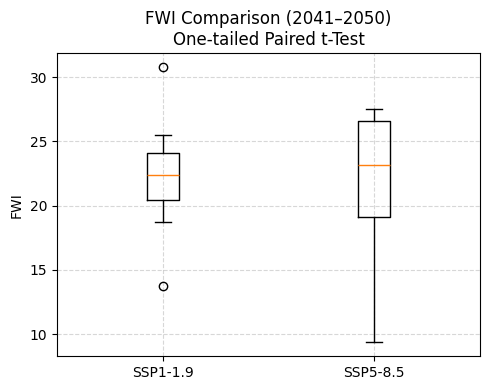

------------------------------------------------------------


In [9]:
# SSP1-1.9 vs SSP5-8.5  |  2041–2050
compare_ssp_same_decade(
    fwi_2041_2050_SSP119, fwi_2041_2050_SSP585,
    ssp1_label="SSP1-1.9", ssp2_label="SSP5-8.5",
    decade="2041–2050",
    filename="Pict/fwi_comparison_2041s_119_585"
)

Shapiro-Wilk p-value (SSP1-1.9): 0.8795
Shapiro-Wilk p-value (SSP3-7.0): 0.9758

Test: One-tailed Paired t-Test
p-value: 0.5185
Result: Fail to reject H₀ — no significant evidence that FWI of SSP3-7.0 exceeds SSP1-1.9.

Mean FWI (SSP1-1.9):         22.25
Mean FWI (SSP3-7.0):         22.15
Mean Difference (ssp2 − ssp1): -0.10
95% CI:                        (-4.27, 4.07)
Cohen's d:                     -0.02 (Very small)


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_70613/3298970299.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([fwi_ssp1, fwi_ssp2], labels=[ssp1_label, ssp2_label])


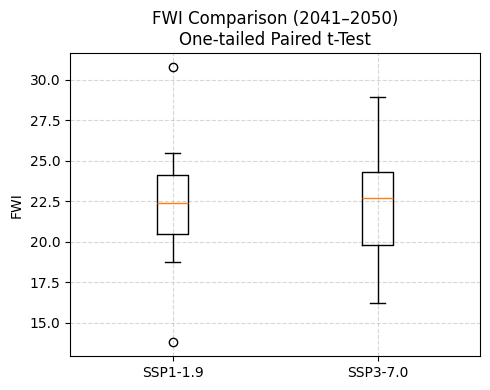

------------------------------------------------------------


In [10]:
# SSP1-1.9 vs SSP3-7.0  |  2041–2050
compare_ssp_same_decade(
    fwi_2041_2050_SSP119, fwi_2041_2050_SSP370,
    ssp1_label="SSP1-1.9", ssp2_label="SSP3-7.0",
    decade="2041–2050",
    filename="Pict/fwi_comparison_2041s_119_370"
)

Shapiro-Wilk p-value (SSP1-1.9): 0.7274
Shapiro-Wilk p-value (SSP5-8.5): 0.1758

Test: One-tailed Paired t-Test
p-value: 0.1898
Result: Fail to reject H₀ — no significant evidence that FWI of SSP5-8.5 exceeds SSP1-1.9.

Mean FWI (SSP1-1.9):         22.55
Mean FWI (SSP5-8.5):         24.18
Mean Difference (ssp2 − ssp1): 1.63
95% CI:                        (-2.28, 5.54)
Cohen's d:                     0.42 (Small)


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_70613/3298970299.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([fwi_ssp1, fwi_ssp2], labels=[ssp1_label, ssp2_label])


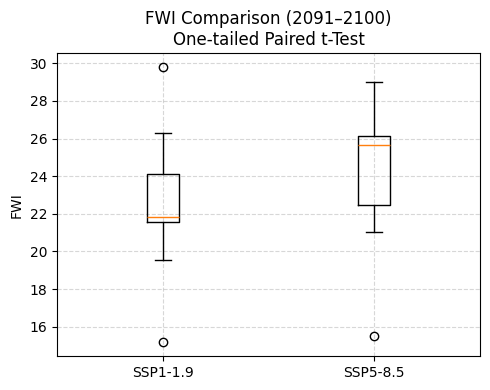

------------------------------------------------------------


In [11]:
# SSP1-1.9 vs SSP5-8.5  |  2091–2100
compare_ssp_same_decade(
    fwi_2091_2100_SSP119, fwi_2091_2100_SSP585,
    ssp1_label="SSP1-1.9", ssp2_label="SSP5-8.5",
    decade="2091–2100",
    filename="Pict/fwi_comparison_2091s_119_585"
)

Shapiro-Wilk p-value (SSP1-1.9): 0.7274
Shapiro-Wilk p-value (SSP3-7.0): 0.1023

Test: One-tailed Paired t-Test
p-value: 0.1305
Result: Fail to reject H₀ — no significant evidence that FWI of SSP3-7.0 exceeds SSP1-1.9.

Mean FWI (SSP1-1.9):         22.55
Mean FWI (SSP3-7.0):         25.28
Mean Difference (ssp2 − ssp1): 2.73
95% CI:                        (-1.59, 7.06)
Cohen's d:                     0.64 (Medium)


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_70613/3298970299.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([fwi_ssp1, fwi_ssp2], labels=[ssp1_label, ssp2_label])


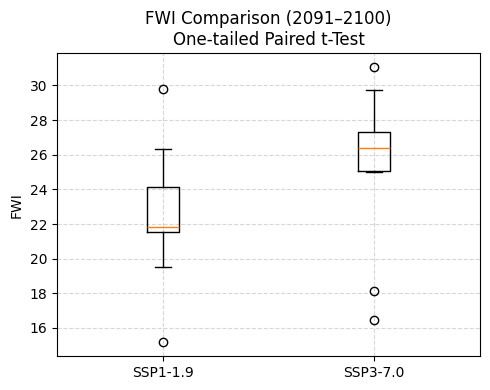

------------------------------------------------------------


In [12]:
# SSP1-1.9 vs SSP3-7.0  |  2091–2100
compare_ssp_same_decade(
    fwi_2091_2100_SSP119, fwi_2091_2100_SSP370,
    ssp1_label="SSP1-1.9", ssp2_label="SSP3-7.0",
    decade="2091–2100",
    filename="Pict/fwi_comparison_2091s_119_370"
)